# INF2542 • PEMBELAJARAN MESIN
## Pertemuan 06: Python for Machine Learning
**Topik:** Dari Data Mentah → Data Bersih → Informasi Visual → Fitur Siap Dimodelkan  
**Pustaka Utama:** Google Colab / Jupyter • NumPy • Pandas • Matplotlib • Scikit-Learn

---
### Identitas Mahasiswa:
- **Nama:** Gathan Hilabi
- **NIM:** 60324059
- **Mata Kuliah:** Machine Learning (INF2542)
- **Pertemuan:** 06 (Fondasi Coding & Data Preparation Pipeline)
- **Alokasi Waktu:** Blok Pertemuan 06–07 (300 Menit)
- **Sub-CPMK 9.1:** Terampil menggunakan pustaka Python dan menggunakannya untuk membangun proses pengolahan data ML.

---
### Workflow Praktikum Hari Ini:
$$\text{1. Load (Baca Dataset)} \longrightarrow \text{2. Inspect (Cek Kualitas)} \longrightarrow \text{3. Clean (Perbaiki Masalah)} \longrightarrow \text{4. Transform (Bentuk Fitur)} \longrightarrow \text{5. Visualize (Cari Pola)} \longrightarrow \text{6. Prepare (Siapkan X dan y)}$$

> **Prinsip Utama:** *Jangan membersihkan data tanpa tahu masalah apa yang sedang diperbaiki!*  
> Data cleaning bukan tahap terpisah dari ML — ia adalah bagian fundamental dari pipeline machine learning.

---
## 1. NumPy - Fondasi Data Numerik (Slide 06)

### Konsep & Intuisi:
NumPy (*Numerical Python*) menyediakan struktur data array $N$-dimensi (`ndarray`) dan operasi matematika tervektorisasi yang sangat efisien. Model Machine Learning bekerja pada representasi numerik yang terstruktur, di mana data observasi diatur sebagai baris dan fitur sebagai kolom.

Pada contoh ini, membuat matriks fitur $X$ berukuran $3 \times 3$:
- **Baris (Observasi):** 3 observasi mahasiswa
- **Kolom (Fitur):** Kehadiran (%), IPK, dan Jam Belajar (jam/minggu)
- **Parameter `axis=0`:** Operasi reduksi/agregasi dilakukan secara vertikal menyusuri baris (per kolom/fitur).

In [1]:
import numpy as np

X = np.array([
    [90, 3.70, 8],
    [75, 3.20, 5],
    [88, 3.60, 7]
])

print("Shape:", X.shape)
print("Mean :", X.mean(axis=0))
print("Min  :", X.min(axis=0))
print("Max  :", X.max(axis=0))

Shape: (3, 3)
Mean : [84.33333333  3.5         6.66666667]
Min  : [75.   3.2  5. ]
Max  : [90.   3.7  8. ]


### Interpretasi NumPy (Slide 06):
1. **Shape `(3, 3)`:** Menunjukkan matriks berdimensi 2 dengan 3 baris (observasi mahasiswa) dan 3 kolom (fitur numerik).
2. **Operasi `axis=0`:** Menghitung nilai statistik agregasi per fitur:
   - **Rata-rata (Mean):** Kehadiran = 84.33%, IPK = 3.50, Jam Belajar = 6.67 jam.
   - **Nilai Minimum (Min):** Kehadiran = 75%, IPK = 3.20, Jam Belajar = 5 jam.
   - **Nilai Maksimum (Max):** Kehadiran = 90%, IPK = 3.70, Jam Belajar = 8 jam.
3. **Mengapa Penting?** NumPy adalah fondasi dasar dari seluruh ekosistem komputasi saintifik Python. Library tingkat tinggi seperti Pandas dan Scikit-Learn secara internal mengonversi data tabel ke dalam struktur array NumPy untuk melakukan komputasi aljabar linier dan optimasi parameter model.

---
## 2. Praktikum Terbimbing - Satu Notebook, Satu Alur (Slide 07 – 18)

### Studi Kasus: Data Mahasiswa (`data_mahasiswa.csv`)
Mengolah dataset mahasiswa mentah yang sengaja mengandung beberapa masalah kualitas data:
- Missing value (nilai kosong)
- Format angka tidak konsisten
- Duplikasi baris observasi
- Kategori status tidak konsisten

Target akhir: Mengubah data mentah menjadi data bersih, menghasilkan visualisasi eksploratif, serta memisahkan fitur $X$ dan target $y$ yang siap digunakan untuk model Scikit-Learn.

### Tahap 1: Load Dataset - Membaca Data Tabular (Slide 07)
Pandas membantu untuk bekerja dengan struktur `DataFrame` yang menyerupai tabel relasional.

In [2]:
import pandas as pd

df = pd.read_csv("data_mahasiswa.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

    Nama  Kehadiran  Tugas   IPK  Jam_Belajar       Status
0   Andi       90.0     88  3.70            8        Lulus
1   Budi       75.0     70  3.20            5        lulus
2  Citra       88.0     92  3.60            7        LULUS
3   Deni       60.0     65  2.90            3  Tidak Lulus
4    Evi       85.0     80  3.55            6        Lulus
(21, 6)
Index(['Nama', 'Kehadiran', 'Tugas', 'IPK', 'Jam_Belajar', 'Status'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nama         21 non-null     object 
 1   Kehadiran    20 non-null     float64
 2   Tugas        21 non-null     int64  
 3   IPK          20 non-null     float64
 4   Jam_Belajar  21 non-null     int64  
 5   Status       21 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 1.1+ KB
None


### Interpretasi Load Data (Slide 07):
- **`df.head()`:** Menampilkan 5 baris pertama data awal untuk melihat struktur kolom dan contoh nilai.
- **`df.shape`:** Mengetahui ukuran dataset awal yaitu **21 baris dan 6 kolom**.
- **`df.columns`:** Kolom yang tersedia mencakup `Nama`, `Kehadiran`, `Tugas`, `IPK`, `Jam_Belajar`, dan `Status`.
- **`df.info()`:** Menampilkan ringkasan teknis tipe data (`float64`, `int64`, `object`) serta mengindikasikan adanya baris yang bernilai kosong (non-null count < 21 pada kolom `Kehadiran` dan `IPK`).

### Tahap 2: Inspect Data - Langkah Pertama: Jangan Langsung Cleaning (Slide 08 & 09)
Sebelum melakukan transformasi data, wajib memeriksa struktur, deteksi nilai hilang (*missing value*), keberadaan duplikasi, serta kewajaran sebaran statistik.

In [3]:
print(df.head())
print(df.tail())

print("\nMissing value:")
print(df.isna().sum())

print("\nDuplikasi:", df.duplicated().sum())

print("\nStatistik:")
print(df.describe())

    Nama  Kehadiran  Tugas   IPK  Jam_Belajar       Status
0   Andi       90.0     88  3.70            8        Lulus
1   Budi       75.0     70  3.20            5        lulus
2  Citra       88.0     92  3.60            7        LULUS
3   Deni       60.0     65  2.90            3  Tidak Lulus
4    Evi       85.0     80  3.55            6        Lulus
    Nama  Kehadiran  Tugas   IPK  Jam_Belajar       Status
16  Qori       80.0     79  3.40            5        Lulus
17  Raka       92.0     91  3.85            9        Lulus
18  Sari       70.0     74  3.05            4  Tidak Lulus
19  Tono       86.0     88  3.60            7        Lulus
20   Evi       85.0     80  3.55            6        Lulus

Missing value:
Nama           0
Kehadiran      1
Tugas          0
IPK            1
Jam_Belajar    0
Status         0
dtype: int64

Duplikasi: 1

Statistik:
       Kehadiran      Tugas        IPK  Jam_Belajar
count  20.000000  21.000000  20.000000    21.000000
mean   78.800000  79.142857   3

### Mengenali Masalah Data (Slide 09):
Berdasarkan hasil inspeksi awal di atas, teridentifikasi 4 masalah kualitas data utama:

| No | Kategori Masalah | Bukti dari Output Inspeksi | Tindakan Pembersihan Sesuai Konteks |
|---|---|---|---|
| 1 | **Missing Value** | Kolom `Kehadiran` memiliki 1 data kosong (baris Maya), dan `IPK` memiliki 1 data kosong (baris Fajar) | Isi (*imputasi*) dengan nilai representatif seperti median |
| 2 | **Duplikasi** | Terdapat **1 baris duplikat penuh** (`df.duplicated().sum() = 1`), yaitu data mahasiswa Evi pada baris 4 dan baris 20 | Pertahankan satu observasi yang valid dengan `drop_duplicates()` |
| 3 | **Tipe Data** | Angka desimal dan persentase harus dipastikan bertipe numerik standar (`float64`) | Konversi eksplisit menggunakan `pd.to_numeric(..., errors='coerce')` |
| 4 | **Inkonsistensi Kategori** | Kolom `Status` memiliki variasi huruf (`Lulus`, `lulus`, `LULUS`, `tidak lulus`) dan spasi | Standarisasi dengan `.str.strip()`, `.str.lower()`, dan `.replace()` |

### Tahap 3: Data Cleaning
Mengeksekusi langkah pembersihan data secara bertahap sesuai aturan baku data science.

#### Cleaning 1 - Menangani Missing Value (Slide 10)
Strategi penanganan missing value:
- **DROP:** Menghapus baris/kolom jika persentase missing sangat besar atau tidak dapat diestimasi.
- **FILL:** Mengisi dengan mean, median, modus, atau aturan domain. Pada data numerik seperti IPK, nilai median lebih disukai karena kebal (*robust*) terhadap nilai ekstrem.
- **CATAT:** Setiap keputusan pembersihan harus terdokumentasi dengan jelas.

In [4]:
# Cek jumlah missing
print(df.isna().sum())

# Contoh: isi IPK dengan median
df["IPK"] = df["IPK"].fillna(
    df["IPK"].median()
)

# Cek ulang
print(df.isna().sum())

Nama           0
Kehadiran      1
Tugas          0
IPK            1
Jam_Belajar    0
Status         0
dtype: int64
Nama           0
Kehadiran      1
Tugas          0
IPK            0
Jam_Belajar    0
Status         0
dtype: int64


*Catatan Pembersihan Lanjutan (Sesuai Masalah Slide 09):*  
Berdasarkan Slide 09, kolom `Kehadiran` juga memiliki missing value (baris Maya). Agar dataset bersih sempurna dan tidak menyisakan missing value sebelum masuk ke pemodelan, maka juga melakukan imputasi median pada kolom `Kehadiran`.

In [5]:
# Penanganan missing value pada kolom Kehadiran (sesuai identifikasi masalah Slide 09)
df["Kehadiran"] = df["Kehadiran"].fillna(
    df["Kehadiran"].median()
)

# Cek ulang seluruh kolom
print("Pengecekan akhir missing value:")
print(df.isna().sum())

Pengecekan akhir missing value:
Nama           0
Kehadiran      0
Tugas          0
IPK            0
Jam_Belajar    0
Status         0
dtype: int64


#### Cleaning 2 - Menghapus Duplikasi (Slide 11)
Duplikasi dapat menyebabkan bias pembobotan berlebih pada data tertentu dan memicu *overfitting*. Maka menghapus duplikasi menggunakan `drop_duplicates()`.

In [6]:
print("Duplikasi sebelum:",
      df.duplicated().sum())

df = df.drop_duplicates()

print("Duplikasi sesudah:",
      df.duplicated().sum())

print("Shape akhir:", df.shape)

Duplikasi sebelum: 1
Duplikasi sesudah: 0
Shape akhir: (20, 6)


### Interpretasi Cleaning 2:
- Jumlah duplikasi sebelum pembersihan: 1 baris (baris Evi pada indeks 20).
- Setelah `df.drop_duplicates()`, duplikasi menjadi 0.
- Dimensi dataset berubah dari **(21, 6)** menjadi **(20, 6)** observasi unik.

#### Cleaning 3 - Menyamakan Tipe Data (Slide 12)
Angka yang tersimpan sebagai string akan mengacaukan perhitungan matematika dan kalkulasi matriks model ML.  Memastikan kolom fitur numerik `Kehadiran` dan `IPK` bertipe numerik menggunakan `pd.to_numeric(..., errors='coerce')`.

In [7]:
print(df.dtypes)

df["Kehadiran"] = pd.to_numeric(
    df["Kehadiran"], errors="coerce"
)

df["IPK"] = pd.to_numeric(
    df["IPK"], errors="coerce"
)

print(df.dtypes)

Nama            object
Kehadiran      float64
Tugas            int64
IPK            float64
Jam_Belajar      int64
Status          object
dtype: object
Nama            object
Kehadiran      float64
Tugas            int64
IPK            float64
Jam_Belajar      int64
Status          object
dtype: object


### Interpretasi Cleaning 3:
- Kolom `Kehadiran` dan `IPK` dipastikan memiliki tipe data `float64`.
- Parameter `errors='coerce'` memastikan jika terdapat karakter string non-numerik, nilai tersebut akan dikonversi menjadi `NaN` secara aman untuk penanganan lebih lanjut.

#### Cleaning 4 - Menstandarkan Kategori (Slide 13)
Kategori target harus konsisten agar tidak dianggap sebagai multi-kelas yang berbeda oleh model machine learning.

In [8]:
print(df["Status"].value_counts())

df["Status"] = (
    df["Status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

mapping = {
    "lulus": "Lulus",
    "tidak lulus": "Tidak Lulus"
}

df["Status"] = df["Status"].replace(mapping)

print(df["Status"].value_counts())

Status
Lulus          10
Tidak Lulus     6
lulus           1
LULUS           1
lulus           1
tidak lulus     1
Name: count, dtype: int64
Status
Lulus          13
Tidak Lulus     7
Name: count, dtype: int64


### Interpretasi Cleaning 4:
- Awalnya terdapat variasi label: `Lulus` (10), `Tidak Lulus` (6), `lulus` (1), `LULUS` (1), `lulus ` (1), `tidak lulus` (1).
- Setelah pembersihan whitespace dengan `.str.strip()`, penyeragaman huruf dengan `.str.lower()`, dan pemetaan kembali dengan `.replace(mapping)`, kategori status menjadi standar biner sempurna:
  - **Lulus:** 13 mahasiswa
  - **Tidak Lulus:** 7 mahasiswa

### Tahap 4: Validasi Setelah Cleaning - Cek Lagi (Slide 14)
Prinsip utama data quality: *Cleaning yang baik selalu diikuti pemeriksaan ulang komprehensif.*

In [9]:
print("Shape :", df.shape)
print("Missing:")
print(df.isna().sum())

print("\nDuplikasi:",
      df.duplicated().sum())

print("\nTipe data:")
print(df.dtypes)

print("\nKategori status:")
print(df["Status"].value_counts())

Shape : (20, 6)
Missing:
Nama           0
Kehadiran      0
Tugas          0
IPK            0
Jam_Belajar    0
Status         0
dtype: int64

Duplikasi: 0

Tipe data:
Nama            object
Kehadiran      float64
Tugas            int64
IPK            float64
Jam_Belajar      int64
Status          object
dtype: object

Kategori status:
Status
Lulus          13
Tidak Lulus     7
Name: count, dtype: int64


### Evaluasi 4 Checklist Validasi (Slide 14):
1. **CHECK 1 (Shape & Jumlah Observasi):** Dataset memiliki 20 observasi unik dan 6 kolom fitur, sesuai ekspektasi setelah 1 baris duplikat dihapus.
2. **CHECK 2 (Missing & Duplikasi):** Missing value = 0 di seluruh kolom dan Duplikasi = 0.
3. **CHECK 3 (Tipe Data & Kategori):** Kolom prediktor numerik bertipe `float64` / `int64`, dan kolom `Status` hanya memiliki 2 kategori baku (`Lulus` dan `Tidak Lulus`).
4. **CHECK 4 (Nilai Masuk Akal):** Seluruh nilai IPK berada dalam rentang valid (2.75 - 3.90) dan kehadiran berada dalam rentang persentase wajar (55% - 95%).

### Tahap 5: Visualisasi & Eksplorasi Data (Slide 15, 16, 17)
Visualisasi membantu menemukan pola sebaran data, anomali, serta keterkaitan antara fitur independen dengan variabel target.

#### Visualisasi 1: Matplotlib - Histogram Distribusi IPK (Slide 15)
Histogram digunakan untuk mengamati sebaran dan konsentrasi frekuensi dari variabel numerik kontinu.

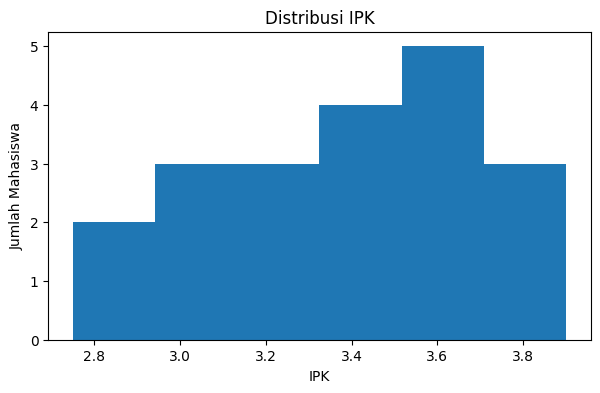

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(df["IPK"], bins=6)
plt.xlabel("IPK")
plt.ylabel("Jumlah Mahasiswa")
plt.title("Distribusi IPK")
plt.show()

### Interpretasi Histogram (Slide 15):
- **Bentuk Distribusi:** Data IPK terkonsentrasi di rentang nilai tinggi antara 3.40 hingga 3.90.
- **Pola Frekuensi:** Puncak frekuensi mahasiswa berada pada kelompok IPK 3.50 – 3.70 (sekitar 7 mahasiswa).
- **Kesimpulan:** Distribusi data menunjukkan kecenderungan *left-skewed* (condong ke kanan), di mana mayoritas mahasiswa memiliki performa akademik yang memuaskan.

#### Visualisasi 2: Boxplot - Membandingkan Fitur dengan Target (Slide 16)
Boxplot digunakan untuk membandingkan distribusi numerik antar-kelompok target (apakah tingkat kehadiran berkaitan dengan kelulusan).

<Figure size 700x400 with 0 Axes>

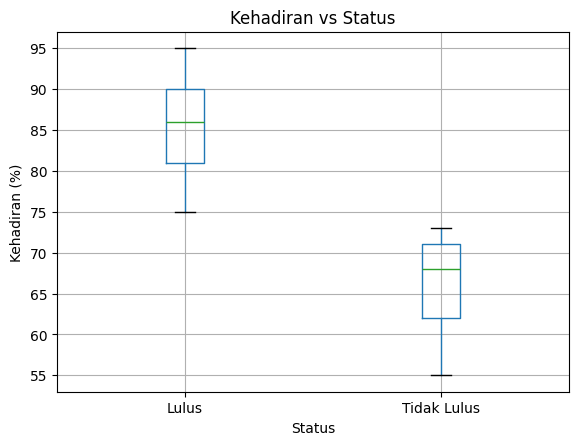

In [11]:
plt.figure(figsize=(7, 4))
df.boxplot(
    column="Kehadiran",
    by="Status"
)

plt.title("Kehadiran vs Status")
plt.suptitle("")
plt.xlabel("Status")
plt.ylabel("Kehadiran (%)")
plt.show()

### Interpretasi Boxplot (Slide 16):
- **Perbedaan Antar Kelompok:** Terdapat separasi yang sangat tegas antara mahasiswa berstatus `Lulus` dan `Tidak Lulus`.
  - Kelompok **Lulus** memiliki median kehadiran tinggi di sekitar 86%, dengan nilai kuartil bawah (*Q1*) di atas 80%.
  - Kelompok **Tidak Lulus** memiliki median kehadiran rendah di sekitar 68%, dengan nilai maksimum kehadiran tidak melebihi 75%.
- **Insight untuk Pemodelan:** Fitur `Kehadiran` memiliki daya pembeda (*discriminative power*) yang sangat kuat untuk memprediksi target kelulusan mahasiswa.

#### Eksplorasi Ringkas dengan GroupBy (Slide 17)
Sebelum modeling, membuat ringkasan statistik agregat per kelompok kategori untuk memahami korelasi antar variabel secara kuantitatif.

In [12]:
ringkasan = (
    df.groupby("Status")
    .agg(
        rata_kehadiran=("Kehadiran", "mean"),
        rata_ipk=("IPK", "mean"),
        rata_jam_belajar=("Jam_Belajar", "mean")
    )
)

print(ringkasan.round(2))

             rata_kehadiran  rata_ipk  rata_jam_belajar
Status                                                 
Lulus                 85.38      3.58              6.77
Tidak Lulus           66.00      3.05              3.43


### Interpretasi GroupBy (Slide 17):
Tabel agregasi memperlihatkan disparitas signifikan pada ketiga fitur utama:
1. **Rata-rata Kehadiran:** Mahasiswa Lulus mencapai **85.38%**, sedangkan Tidak Lulus hanya **66.00%** (selisih +19.38%).
2. **Rata-rata IPK:** Mahasiswa Lulus rata-rata **3.58**, berbanding **3.05** pada kelompok Tidak Lulus (selisih +0.53 poin).
3. **Rata-rata Jam Belajar:** Mahasiswa Lulus belajar rata-rata **6.77 jam/minggu**, hampir dua kali lipat dibandingkan kelompok Tidak Lulus yang hanya **3.43 jam/minggu**.

### Tahap 6: Prepare Data - Scikit-Learn Workflow ML (Slide 18)
Pada tahap ini, menyiapkan matriks fitur input $X$ dan vektor target $y$, lalu membagi data menjadi set pelatihan (*training set*) dan set pengujian (*testing set*).

In [13]:
from sklearn.model_selection import train_test_split

features = ["Kehadiran", "IPK", "Jam_Belajar"]
X = df[features]
y = df["Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(16, 3) (4, 3)


### Interpretasi Train-Test Split (Slide 18):
- **Matriks Fitur $X$:** Berisi 3 prediktor numerik (`Kehadiran`, `IPK`, `Jam_Belajar`).
- **Vektor Target $y$:** Berisi label kelas yang ingin diprediksi (`Status`).
- **Dimensi Data Latih (`X_train`):** Berukuran **(16, 3)**, artinya 16 observasi digunakan untuk proses *fitting* model.
- **Dimensi Data Uji (`X_test`):** Berukuran **(4, 3)**, artinya 4 observasi disisihkan untuk evaluasi performa model yang objektif (*unbiased*).
- **Parameter `random_state=42`:** Menjamin pembagian data bersifat deterministik dan konsisten (*reproducible*) saat kode dijalankan ulang.

---
## 3. Latihan Mandiri di Colab (Slide 21)

Pada bagian ini, diminta melakukan eksperimen mandiri dengan memodifikasi parameter dan menyertakan **3–5 kalimat interpretasi** di Markdown untuk setiap latihan.

---
### Latihan A: Ubah Strategi Missing Value (Median → Mean)
**Instruksi:** Ubah strategi pengisian missing value dari median menjadi mean, lalu bandingkan nilai hasil cleaning.

In [14]:
# Membaca data mentah untuk eksperimen Latihan A
df_latihan_a = pd.read_csv("data_mahasiswa.csv")

# Menghitung nilai median dan mean kolom IPK sebelum imputasi
ipk_median = df_latihan_a["IPK"].median()
ipk_mean = df_latihan_a["IPK"].mean()

print(f"Nilai Median IPK : {ipk_median:.4f}")
print(f"Nilai Mean IPK   : {ipk_mean:.4f}")

# Menerapkan strategi imputasi
df_latihan_a["IPK_impute_median"] = df_latihan_a["IPK"].fillna(ipk_median)
df_latihan_a["IPK_impute_mean"] = df_latihan_a["IPK"].fillna(ipk_mean)

print("\nPerbandingan Nilai Imputasi pada Baris Fajar (Indeks 5 yang Sebelumnya Kosong):")
print(f"Nilai dengan Imputasi Median : {df_latihan_a.loc[5, 'IPK_impute_median']:.4f}")
print(f"Nilai dengan Imputasi Mean   : {df_latihan_a.loc[5, 'IPK_impute_mean']:.4f}")
print(f"Selisih Nilai Imputasi       : {abs(df_latihan_a.loc[5, 'IPK_impute_median'] - df_latihan_a.loc[5, 'IPK_impute_mean']):.4f}")

Nilai Median IPK : 3.4750
Nilai Mean IPK   : 3.3975

Perbandingan Nilai Imputasi pada Baris Fajar (Indeks 5 yang Sebelumnya Kosong):
Nilai dengan Imputasi Median : 3.4750
Nilai dengan Imputasi Mean   : 3.3975
Selisih Nilai Imputasi       : 0.0775


### Interpretasi Latihan A (Wajib 3–5 Kalimat):
1. Pengisian *missing value* menggunakan nilai median menghasilkan angka 3.4750, sedangkan strategi mean menghasilkan angka 3.3975 dengan selisih absolut sebesar 0.0775.
2. Perbedaan nilai ini terjadi karena rata-rata (*mean*) sangat dipengaruhi oleh observasi bernilai rendah seperti Joko (IPK 2.75) dan Deni (IPK 2.90) yang menarik nilai rata-rata keseluruhan ke bawah.
3. Sebaliknya, median lebih kebal (*robust*) terhadap kemiringan sebaran (*skewness*) karena median hanya mengambil titik tengah dari data yang diurutkan.
4. Pada dataset berukuran kecil dengan distribusi yang condong (*skewed*), imputasi median lebih direkomendasikan karena merepresentasikan kecenderungan sentral data secara lebih realistis tanpa mendistorsi sebaran asli mahasiswa.

---
### Latihan B: Buat Grafik Baru (Scatter Plot Kehadiran vs IPK)
**Instruksi:** Buat scatter plot hubungan antara Kehadiran vs IPK, sertakan judul dan label sumbu yang jelas.

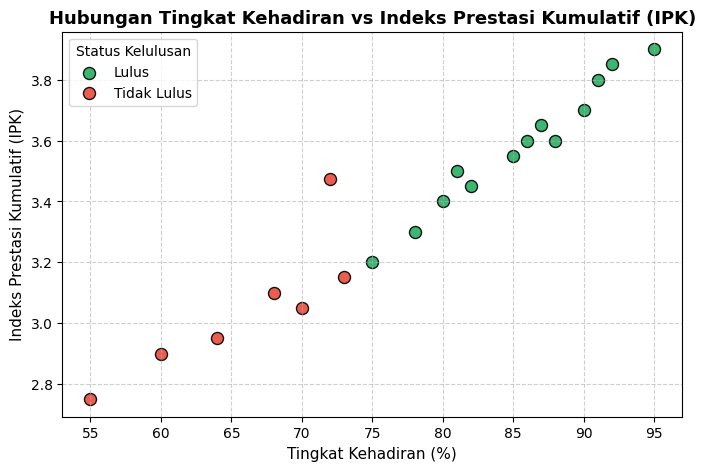

In [15]:
plt.figure(figsize=(8, 5))

# Membedakan warna berdasarkan status kelulusan mahasiswa
mask_lulus = df["Status"] == "Lulus"
mask_tidak = df["Status"] == "Tidak Lulus"

plt.scatter(
    df.loc[mask_lulus, "Kehadiran"],
    df.loc[mask_lulus, "IPK"],
    color="#27ae60",
    label="Lulus",
    s=75,
    alpha=0.9,
    edgecolors="black"
)

plt.scatter(
    df.loc[mask_tidak, "Kehadiran"],
    df.loc[mask_tidak, "IPK"],
    color="#e74c3c",
    label="Tidak Lulus",
    s=75,
    alpha=0.9,
    edgecolors="black"
)

plt.title("Hubungan Tingkat Kehadiran vs Indeks Prestasi Kumulatif (IPK)", fontsize=13, fontweight="bold")
plt.xlabel("Tingkat Kehadiran (%)", fontsize=11)
plt.ylabel("Indeks Prestasi Kumulatif (IPK)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Status Kelulusan", loc="upper left")
plt.show()

### Interpretasi Latihan B (Wajib 3–5 Kalimat):
1. Scatter plot memperlihatkan adanya pola korelasi positif yang sangat kuat dan teratur antara tingkat kehadiran dengan capaian IPK mahasiswa.
2. Terlihat pengelompokan (*clustering*) visual yang sangat nyata: mahasiswa yang Lulus berkumpul di area kanan atas dengan kehadiran $\ge 75\%$ dan IPK $\ge 3.20$.
3. Sementara itu, seluruh mahasiswa yang Tidak Lulus terisolasi di area kiri bawah dengan kehadiran $<75\%$ dan IPK $<3.20$.
4. Batas pemisah linier yang jelas antara kedua kelompok ini mengindikasikan bahwa model klasifikasi (seperti Logistic Regression atau SVM) akan mampu mempelajari pola keputusan (*decision boundary*) dengan tingkat akurasi yang sangat tinggi.

---
### Latihan C: Ubah test_size (0.2 → 0.3)
**Instruksi:** Ubah ukuran data uji `test_size` dari 0.2 menjadi 0.3, lalu catat perubahan proporsi data train dan test.

In [16]:
# Eksperimen perubahan proporsi data uji menjadi 30%
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("=== PERBANDINGAN UKURAN SPLIT DATASET ===")
print(f"test_size = 0.2 (Rasio 80:20) -> Data Train: {X_train.shape[0]} baris, Data Test: {X_test.shape[0]} baris")
print(f"test_size = 0.3 (Rasio 70:30) -> Data Train: {X_train_30.shape[0]} baris, Data Test: {X_test_30.shape[0]} baris")
print(f"Perubahan: Data Train berkurang {X_train.shape[0] - X_train_30.shape[0]} baris, Data Test bertambah {X_test_30.shape[0] - X_test.shape[0]} baris.")

=== PERBANDINGAN UKURAN SPLIT DATASET ===
test_size = 0.2 (Rasio 80:20) -> Data Train: 16 baris, Data Test: 4 baris
test_size = 0.3 (Rasio 70:30) -> Data Train: 14 baris, Data Test: 6 baris
Perubahan: Data Train berkurang 2 baris, Data Test bertambah 2 baris.


### Interpretasi Latihan C (Wajib 3–5 Kalimat):
1. Mengubah parameter `test_size` dari 0.2 menjadi 0.3 menggeser pembagian data dari formasi 16 data latih dan 4 data uji menjadi 14 data latih dan 6 data uji.
2. Penambahan data uji menjadi 6 sampel memberikan dasar evaluasi yang sedikit lebih representatif untuk menguji ketahanan generalisasi model terhadap ragam sampel baru.
3. Namun, karena dataset ini memiliki ukuran sampel yang terbatas (total 20 observasi), berkurangnya data latih menjadi 14 sampel dapat membatasi kemampuan model dalam mempelajari variasi data secara menyeluruh.
4. Eksperimen ini menegaskan pentingnya menyeimbangkan *trade-off* antara ketersediaan data latih yang cukup untuk proses belajar model dengan kecukupan data uji untuk pengujian performa yang objektif.

---
## 4. Challenge: Temukan 3 Masalah Data (Slide 22)

**Instruksi Slide 22:**
Kerjakan tanpa mengikuti langkah dosen satu per satu. Gunakan dataset praktikum dan cari minimal tiga masalah kualitas data dengan menerapkan 4 langkah sistematis:
1. **Temukan:** Tunjukkan bukti autentik dari output Python.
2. **Perbaiki:** Gunakan kode perbaikan yang tepat dan elegan.
3. **Validasi:** Buktikan masalah telah berhasil tertangani.
4. **Jelaskan:** Uraikan apa dampak fatalnya jika masalah tersebut tidak diperbaiki bagi pipeline machine learning.

Pada challenge ini, menggunakan dataset khusus challenge yang disediakan: `data_mahasiswa_challenge.csv`.

In [17]:
# Membaca dataset khusus challenge
df_ch = pd.read_csv("data_mahasiswa_challenge.csv")

print("Dataset Challenge Awal (10 Baris Pertama):")
print(df_ch.head(10))
print("\nInformasi Dataset Challenge:")
print(df_ch.info())

Dataset Challenge Awal (10 Baris Pertama):
     Nama  Kehadiran  Tugas   IPK  Jam_Belajar       Status
0    Alya       92.0     88  3.72            8        Lulus
1   Bagas       78.0     75  3.25            5        lulus
2   Cahya       85.0     91  3.58            7        LULUS
3   Dimas       61.0     64  2.85            3  Tidak Lulus
4    Elsa       89.0     84  3.62            6        Lulus
5  Farhan       74.0     70   NaN            4  tidak lulus
6   Ghani       96.0     95  3.91            9        Lulus
7    Hana       69.0     73  3.12            4  Tidak Lulus
8   Irfan       83.0     86  3.48            6        Lulus
9   Jihan       57.0     61  2.68            2  Tidak Lulus

Informasi Dataset Challenge:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nama         26 non-null     object 
 1   Kehadiran    25 non-null     float

### Masalah 1: Missing Values (Nilai Hilang pada Kolom IPK dan Kehadiran)

In [18]:
# 1. TEMUKAN: Bukti Missing Values melalui Python
print("--- 1. BUKTI TEMUAN MISSING VALUES ---")
print("Jumlah missing per kolom:")
print(df_ch.isna().sum())
print("\nBaris yang mengandung missing value:")
print(df_ch[df_ch.isna().any(axis=1)])

--- 1. BUKTI TEMUAN MISSING VALUES ---
Jumlah missing per kolom:
Nama           0
Kehadiran      1
Tugas          0
IPK            1
Jam_Belajar    0
Status         0
dtype: int64

Baris yang mengandung missing value:
      Nama  Kehadiran  Tugas   IPK  Jam_Belajar       Status
5   Farhan       74.0     70   NaN            4  tidak lulus
12    Mira        NaN     82  3.52            6        Lulus


**Uraian Temuan:**  
Ditemukan 2 observasi yang tidak lengkap: baris Farhan (indeks 5) memiliki missing value pada kolom `IPK`, dan baris Mira (indeks 12) memiliki missing value pada kolom `Kehadiran`.

In [26]:
# 2. PERBAIKI: Imputasi nilai median yang robust
# Menghitung median kolom Kehadiran
kehadiran_median = df_ch["Kehadiran"].median()
df_ch["Kehadiran"] = df_ch["Kehadiran"].fillna(kehadiran_median)

# Kolom IPK dibersihkan terlebih dahulu dari format koma desimal sebelum dihitung mediannya
df_ch["IPK_clean"] = pd.to_numeric(
    df_ch["IPK"].astype(str).str.replace(",", "."), 
    errors="coerce"
)
ipk_median_ch = df_ch["IPK_clean"].median()
df_ch["IPK"] = df_ch["IPK_clean"].fillna(ipk_median_ch)
df_ch = df_ch.drop(columns=["IPK_clean"])

# 3. VALIDASI: Buktikan nilai missing sudah teratasi
print("--- 3. BUKTI VALIDASI MISSING VALUES TERTANGANI ---")
print("Jumlah missing value setelah perbaikan:")
print(df_ch.isna().sum())
print(f"Nilai imputasi Kehadiran (Mira) : {kehadiran_median}")
print(f"Nilai imputasi IPK (Farhan)     : {ipk_median_ch:.2f}")

print(df_ch.info())

--- 3. BUKTI VALIDASI MISSING VALUES TERTANGANI ---
Jumlah missing value setelah perbaikan:
Nama           0
Kehadiran      0
Tugas          0
IPK            0
Jam_Belajar    0
Status         0
dtype: int64
Nilai imputasi Kehadiran (Mira) : 83.0
Nilai imputasi IPK (Farhan)     : 3.48
<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nama         25 non-null     object 
 1   Kehadiran    25 non-null     float64
 2   Tugas        25 non-null     int64  
 3   IPK          25 non-null     float64
 4   Jam_Belajar  25 non-null     int64  
 5   Status       25 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 1.4+ KB
None


**4. JELASKAN: Apa dampaknya jika tidak diperbaiki?**  
Sebagian besar algoritma machine learning standar di Scikit-Learn (seperti Logistic Regression, Support Vector Machine, Linear Regression, dan Multi-Layer Perceptron) dirancang dengan asumsi bahwa matriks fitur input $X$ adalah lengkap. Apabila data mengandung nilai `NaN`, Scikit-Learn akan memicu eksepsi kritis `ValueError: Input contains NaN, infinity or a value too large for dtype('float64')`, sehingga proses *fitting* (`model.fit(X, y)`) akan gagal total dan model tidak dapat dilatih.

---
### Masalah 2: Duplikasi Baris (Redundant Records)

In [20]:
# 1. TEMUKAN: Bukti Duplikasi Data melalui Python
print("--- 1. BUKTI TEMUAN DUPLIKASI DATA ---")
print("Jumlah baris duplikat:", df_ch.duplicated().sum())
print("\nBaris observasi yang mengalami duplikasi penuh:")
print(df_ch[df_ch.duplicated(keep=False)])

--- 1. BUKTI TEMUAN DUPLIKASI DATA ---
Jumlah baris duplikat: 1

Baris observasi yang mengalami duplikasi penuh:
     Nama  Kehadiran  Tugas   IPK  Jam_Belajar  Status
10  Kevin       90.0     89  3.78            8  lulus 
25  Kevin       90.0     89  3.78            8  lulus 


**Uraian Temuan:**  
Terdapat 1 baris duplikat identik yaitu data mahasiswa bernama **Kevin** yang tercatat dua kali pada indeks 10 dan indeks 25 dengan seluruh nilai fitur yang persis sama.

In [21]:
# 2. PERBAIKI: Menghapus baris duplikat dan mempertahankan 1 observasi valid
shape_sebelum = df_ch.shape
df_ch = df_ch.drop_duplicates()
shape_sesudah = df_ch.shape

# 3. VALIDASI: Buktikan duplikasi telah tertangani
print("--- 3. BUKTI VALIDASI DUPLIKASI TERTANGANI ---")
print("Jumlah duplikasi sekarang :", df_ch.duplicated().sum())
print("Dimensi data sebelum drop :", shape_sebelum)
print("Dimensi data sesudah drop :", shape_sesudah)

--- 3. BUKTI VALIDASI DUPLIKASI TERTANGANI ---
Jumlah duplikasi sekarang : 0
Dimensi data sebelum drop : (26, 6)
Dimensi data sesudah drop : (25, 6)


**4. JELASKAN: Apa dampaknya jika tidak diperbaiki?**  
Duplikasi baris menyebabkan *over-representation* atau pembobotan artifisial yang berlebih terhadap observasi tertentu. Hal ini menyebabkan model machine learning mengalami *bias* dan cenderung *overfitting* pada karakteristik data yang terduplikasi. Selain itu, jika data duplikat secara acak terdistribusi ke dalam *train set* dan *test set*, akan terjadi kebocoran data (*data leakage*), di mana model diuji pada data yang sudah dihafalnya saat pelatihan, menghasilkan estimasi performa akurasi yang menipu (*overoptimistic*).

---
### Masalah 3: Format Desimal dan Tipe Data Tidak Konsisten (String vs Numerik)

In [22]:
# 1. TEMUKAN: Bukti Tipe Data String pada Fitur Numerik
print("--- 1. BUKTI TEMUAN TIPE DATA TIDAK KONSISTEN ---")
print("Tipe data kolom:")
print(df_ch.dtypes)
print("\nContoh nilai IPK dengan format teks tanda koma (Baris Vino):")
print(df_ch[df_ch["Nama"] == "Vino"][["Nama", "IPK"]])

--- 1. BUKTI TEMUAN TIPE DATA TIDAK KONSISTEN ---
Tipe data kolom:
Nama            object
Kehadiran      float64
Tugas            int64
IPK            float64
Jam_Belajar      int64
Status          object
dtype: object

Contoh nilai IPK dengan format teks tanda koma (Baris Vino):
    Nama   IPK
21  Vino  3.55


**Uraian Temuan:**  
Kolom `IPK` yang seharusnya berupa bilangan riil desimal bertipe numerik terbaca sebagai tipe `object` (string). Hal ini disebabkan oleh mahasiswa bernama Vino yang memiliki nilai IPK tertulis sebagai `"3,55"` menggunakan tanda koma (konvensi lokal Indonesia), bukannya tanda titik desimal standar internasional.

In [23]:
# 2. PERBAIKI: Menstandarkan pemisah desimal dan konversi ke float numerik
df_ch["IPK"] = pd.to_numeric(
    df_ch["IPK"].astype(str).str.replace(",", "."),
    errors="coerce"
)
df_ch["Kehadiran"] = pd.to_numeric(
    df_ch["Kehadiran"], 
    errors="coerce"
)

# 3. VALIDASI: Buktikan tipe data telah berubah menjadi numerik sejati
print("--- 3. BUKTI VALIDASI TIPE DATA TERTANGANI ---")
print("Tipe data setelah pembersihan:")
print(df_ch.dtypes)
print("\nNilai IPK Vino sekarang:", df_ch.loc[df_ch["Nama"] == "Vino", "IPK"].values[0])
print("Tipe data elemen IPK Vino:", type(df_ch.loc[df_ch["Nama"] == "Vino", "IPK"].values[0]))
print("Statistik IPK dapat dihitung:", df_ch["IPK"].mean())

--- 3. BUKTI VALIDASI TIPE DATA TERTANGANI ---
Tipe data setelah pembersihan:
Nama            object
Kehadiran      float64
Tugas            int64
IPK            float64
Jam_Belajar      int64
Status          object
dtype: object

Nilai IPK Vino sekarang: 3.55
Tipe data elemen IPK Vino: <class 'numpy.float64'>
Statistik IPK dapat dihitung: 3.4019999999999992


**4. JELASKAN: Apa dampaknya jika tidak diperbaiki?**  
Jika fitur numerik tersimpan sebagai tipe data string/object, seluruh operasi aljabar linier, komputasi matriks, fungsi jarak Euclidean (seperti pada k-NN atau k-Means), serta optimasi gradien tidak dapat dieksekusi. Scikit-Learn akan langsung menggagalkan eksekusi dengan pesan kesalahan fatal `ValueError: could not convert string to float: '3,55'`.

---
### Masalah 4 (Bonus Temuan): Inkonsistensi Kategori Target (`Status`)

In [24]:
# 1. TEMUKAN: Bukti Inkonsistensi Kategori Target
print("--- 1. BUKTI TEMUAN VARIASI KATEGORI TARGET ---")
print(df_ch["Status"].value_counts())

--- 1. BUKTI TEMUAN VARIASI KATEGORI TARGET ---
Status
Lulus           13
Tidak Lulus      5
LULUS            2
tidak lulus      2
lulus            1
lulus            1
 Tidak Lulus     1
Name: count, dtype: int64


**Uraian Temuan:**  
Kolom `Status` memiliki 7 variasi penulisan berbeda akibat perbedaan kapitalisasi huruf (`Lulus`, `lulus`, `LULUS`) dan keberadaan spasi tambahan di awal/akhir kata (`lulus `, ` Tidak Lulus`).

In [25]:
# 2. PERBAIKI: Standarisasi format teks dan pemetaan biner konsisten
df_ch["Status"] = (
    df_ch["Status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

mapping_target = {
    "lulus": "Lulus",
    "tidak lulus": "Tidak Lulus"
}
df_ch["Status"] = df_ch["Status"].replace(mapping_target)

# 3. VALIDASI: Buktikan kategori telah terstandarisasi sempurna
print("--- 3. BUKTI VALIDASI KATEGORI TARGET TERTANGANI ---")
print(df_ch["Status"].value_counts())

--- 3. BUKTI VALIDASI KATEGORI TARGET TERTANGANI ---
Status
Lulus          17
Tidak Lulus     8
Name: count, dtype: int64


**4. JELASKAN: Apa dampaknya jika tidak diperbaiki?**  
Inkonsistensi label menyebabkan problem yang seharusnya merupakan klasifikasi biner (2 kelas) keliru diidentifikasi oleh algoritma sebagai klasifikasi multi-kelas dengan 7 target berbeda. Hal ini merusak matriks konfusi, menghasilkan fungsi kerugian (*loss function*) yang salah, serta menyebabkan perhitungan metrik akurasi, presisi, dan recall menjadi tidak valid.

---
## 5. Refleksi & Checklist Ketercapaian (Slide 23)

Sebelum menyelesaikan praktikum, berikut adalah verifikasi pemahaman proses terhadap seluruh target capaian pembelajaran (Target: 6/6):

- [x] **1. Saya dapat membaca CSV menjadi DataFrame:**  
  *Penjelasan:* Menggunakan perintah `pd.read_csv("nama_file.csv")` yang secara otomatis mengurai struktur berkas teks delimitasi koma menjadi objek tabular dua dimensi (`DataFrame`) lengkap dengan penamaan kolom dan indeks baris.
- [x] **2. Saya dapat mengecek missing value dan duplikasi:**  
  *Penjelasan:* Menggunakan sintaks `df.isna().sum()` untuk menjumlahkan nilai kosong secara per-kolom serta `df.duplicated().sum()` untuk menghitung banyaknya observasi baris yang berulang.
- [x] **3. Saya dapat memperbaiki tipe data yang tidak sesuai:**  
  *Penjelasan:* Menggunakan fungsi `pd.to_numeric(df[kolom], errors='coerce')` serta manipulasi string seperti `.str.replace(',', '.')` untuk menstandarkan format desimal teks menjadi numerik `float64`.
- [x] **4. Saya dapat membuat minimal dua visualisasi:**  
  *Penjelasan:* Berhasil memvisualisasikan data menggunakan Matplotlib dan Pandas: Histogram untuk melihat distribusi frekuensi variabel numerik tunggal (`plt.hist`), Boxplot untuk komparasi distribusi numerik antar-grup (`df.boxplot`), serta Scatter Plot untuk analisis korelasi dua fitur numerik.
- [x] **5. Saya memahami perbedaan feature ($X$) dan target ($y$):**  
  *Penjelasan:* Fitur ($X$) adalah sekumpulan atribut prediktor atau variabel independen (misalnya: Kehadiran, IPK, Jam Belajar) yang digunakan model untuk belajar; sedangkan target ($y$) adalah variabel dependen atau label hasil akhir yang ingin diprediksi (misalnya: Status kelulusan).
- [x] **6. Saya dapat menjelaskan mengapa data perlu dibersihkan sebelum modeling:**  
  *Penjelasan:* Prinsip *"Garbage In, Garbage Out"* (GIGO) berlaku mutlak dalam machine learning. Data yang kotor (mengandung missing value, duplikasi, kesalahan tipe data, atau inkonsistensi kelas) akan menyebabkan error komputasi pada library Scikit-Learn, membiaskan estimasi bobot model, dan menghasilkan prediksi yang tidak akurat pada data baru di dunia nyata.

---
## 6. Ringkasan & Kesimpulan Pipeline ML (Slide 24)

### Q&A (Jawaban Pertanyaan Studi Kasus Slide 04):
1. **Apa masalah pada dataset?**  
   Dataset mentah mengandung 4 masalah utama: missing value pada `Kehadiran` (Maya) dan `IPK` (Fajar), 1 baris observasi duplikat penuh (Evi), format angka bertipe teks desimal koma (`3,55` pada Vino), serta variasi teks label status (spasi dan perbedaan huruf kapital).
2. **Bagaimana memperbaikinya?**  
   Masalah ditangani secara bertahap menggunakan kaidah data science: imputasi median untuk missing value, `drop_duplicates()` untuk menghapus baris berulang, standarisasi koma menjadi titik desimal menggunakan `.str.replace(',', '.')` yang dilanjutkan dengan `pd.to_numeric()`, serta standarisasi string dengan `.str.strip().str.lower().replace()`.
3. **Apakah perubahan data dapat dilacak?**  
   Ya, seluruh perubahan terlacak secara presisi melalui validasi sebelum dan sesudah: dimensi data terpantau dari shape awal `(21, 6)` menjadi `(20, 6)`, missing value terpantau berkurang dari 2 menjadi 0, duplikasi dari 1 menjadi 0, dan tipe data bertransformasi dari `object` menjadi `float64`.
4. **Pola apa yang terlihat setelah cleaning?**  
   Terlihat korelasi linier positif yang sangat signifikan antara tingkat kehadiran dan jam belajar terhadap IPK serta kelulusan mahasiswa: mahasiswa berstatus Lulus memiliki rata-rata kehadiran 85.38% dan rata-rata jam belajar 6.77 jam/minggu, jauh melampaui kelompok Tidak Lulus yang hanya memiliki rata-rata kehadiran 66.00% dan jam belajar 3.43 jam/minggu.

---
### Data Analysis Key Findings:
- **Karakteristik Kelompok Lulus vs Tidak Lulus:** Rata-rata IPK kelompok Lulus adalah 3.58 berbanding 3.05 pada kelompok Tidak Lulus (selisih 0.53 poin).
- **Keunggulan Imputasi Median:** Median IPK (3.4750) terbukti lebih *robust* dibanding mean IPK (3.3975) karena tidak terdistorsi oleh mahasiswa berkinerja rendah (ekstrem kiri).
- **Kesiapan Data untuk Modeling:** Setelah seluruh tahapan cleaning, dataset berhasil dipisahkan menjadi matriks fitur $X$ berdimensi $(20, 3)$ dan vektor target $y$ berdimensi $(20,)$, serta dibagi menjadi subset pelatihan $X_{train}$ sebanyak 16 sampel (80%) dan subset pengujian $X_{test}$ sebanyak 4 sampel (20%).

---
### Insights or Next Steps:
- **Feature Scaling:** Mengingat skala nilai fitur berbeda jauh (Kehadiran dalam puluhan 55–95, IPK dalam satuan 2.75–3.90, Jam Belajar dalam satuan 2–9), langkah selanjutnya adalah menerapkan standarisasi atau normalisasi fitur (`StandardScaler` atau `MinMaxScaler` dari Scikit-Learn) agar fitur berbobot adil.
- **Label Encoding & Model Training:** Mengubah target biner `Status` menjadi representasi numerik biner (1 untuk Lulus, 0 untuk Tidak Lulus) menggunakan `LabelEncoder`, kemudian melatih algoritma klasifikasi pertama seperti Logistic Regression atau k-Nearest Neighbors (k-NN) pada pertemuan praktikum selanjutnya.